## Lab 9 — News Summarization using Transformers

**Date:** 14 Apr 2026

---

### Objectives
* **Fine-tune** a transformer-based model to summarize descriptive news.
* **Explore** different transformer variants — architectures, token limits, and parameter counts.
* **Select** a BART variant suitable for free compute (Colab / Kaggle).
* **Load** a pretrained model from HuggingFace and fine-tune on ILSUM-1.0 English.
* **Study** evaluation metrics for text summarization tasks.
* **Evaluate** the fine-tuned model on the test set using **ROUGE** and **BERTScore**.

### Dataset
* **Indian Language Summarization Dataset** — [ILSUM/ILSUM-1.0](https://huggingface.co/datasets/ILSUM/ILSUM-1.0)
* **Subset used:** English
* **Filters:**
    * Articles ≤ 900 tokens
    * Training samples > 1,000
    * Same filters applied to validation and test sets

---
## 1. Transformer Model Variants — Overview

### 1.1 Encoder-Only Models  *(Classification · NER · Extractive QA)*
Read input bidirectionally — best for tasks requiring deep text understanding.

| Model | Max Tokens | Parameters | Primary Tasks |
|---|:---:|:---:|---|
| BERT-base | 512 | 110M | Classification, NER, QA |
| BERT-large | 512 | 340M | Same, higher capacity |
| RoBERTa-base | 512 | 125M | Classification, NER |
| DistilBERT | 512 | 66M | Fast/lightweight classification |
| DeBERTa-v3-base | 512 | 86M | Classification, NLI |

### 1.2 Decoder-Only Models  *(Text Generation)*
Autoregressive — generate one token at a time. Best for open-ended generation.

| Model | Max Tokens | Parameters | Primary Tasks |
|---|:---:|:---:|---|
| GPT-2 | 1024 | 117M–1.5B | Text generation, completion |
| GPT-3 | 4096 | 175B | Generation, chat |
| LLaMA-2-7B | 4096 | 7B | General generation |
| Mistral-7B | 8192 | 7B | Efficient generation |

### 1.3 Encoder-Decoder Models  *(Seq2Seq — Summarization · Translation · QA)*
Encoder reads input; decoder generates output. **Purpose-built for summarization.**

| Model | Max Tokens | Parameters | Primary Tasks |
|---|:---:|:---:|---|
| **BART-base**  | **1024** | **139M** | **Seq2Seq, Summarization** |
| BART-large | 1024 | 406M | Summarization (higher quality) |
| BART-large-cnn | 1024 | 406M | Pre-finetuned on CNN/DM |
| T5-small | 512 | 60M | Text-to-Text (all NLP tasks) |
| T5-base | 512 | 220M | Same, more capacity |
| T5-large | 512 | 770M | Better quality, more VRAM |
| Pegasus-large | 1024 | 568M | Summarization (gap-sentence pretraining) |
| mBART-large-50 | 1024 | 610M | Multilingual summarization |
| LED-base | 16384 | 162M | Long-document summarization |
| BigBird-Pegasus | 4096 | 568M | Long-document summarization |

---

### 1.4 Selected Model: `facebook/bart-base` 

> | Property | Value |
> |---|---|
> | **HuggingFace ID** | `facebook/bart-base` |
> | **Parameters** | ~139 Million |
> | **Max Input Tokens** | 1024 |
> | **Architecture** | Encoder-Decoder (seq2seq) |
> | **Pretraining** | Denoising (masking, deletion, permutation) |

**Why BART-base over other variants?**
- Fits comfortably on a free **T4 GPU (16 GB VRAM)** with `fp16` and batch size 8
- `BART-large` (406M) and `Pegasus-large` (568M) cause OOM on free-tier during fine-tuning
- 1024-token limit covers most news articles without any truncation loss
- Denoising pretraining transfers naturally to abstractive summarization
- Battle-tested with HuggingFace `Seq2SeqTrainer`

---
## 2. Evaluation Metrics for Text Summarization

### 2.1 ROUGE *(Recall-Oriented Understudy for Gisting Evaluation)*
Compares n-gram overlap between generated and reference summary.

| Metric | What it measures | Range |
|---|---|:---:|
| **ROUGE-1** | Unigram (word) overlap — basic content coverage | 0–1 |
| **ROUGE-2** | Bigram overlap — phrase-level similarity | 0–1 |
| **ROUGE-L** | Longest Common Subsequence — fluency & word order | 0–1 |
| ROUGE-Lsum | LCS per sentence, then averaged across doc | 0–1 |

Each score has Precision, Recall, F1. We report **F1**.

### 2.2 BERTScore
Uses contextual BERT embeddings to compute token-level cosine similarity between prediction and reference — captures **semantic similarity** even when exact wording differs.

### 2.3 BLEU *(Bilingual Evaluation Understudy)*
Measures n-gram precision with a brevity penalty. Originally for translation — less preferred for abstractive summarization.

### 2.4 METEOR
Considers synonyms and stemming in addition to n-gram overlap. Better human-correlation than ROUGE.

> **Metrics used in this lab:** ROUGE-1, ROUGE-2, ROUGE-L, ROUGE-Lsum, BERTScore-F1

---
## 3. Install Dependencies

In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "datasets", "transformers[torch]", "evaluate",
     "rouge_score", "bert_score", "sentencepiece", "accelerate"],
    check=True
)
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.1 MB/s eta 0:00:00
All packages installed.


---
## 4. Imports & Setup

In [2]:
import os
import warnings
import logging

# ── suppress all the noise ──────────────────────────────────────────────────
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # removes tokenizer fork warning
warnings.filterwarnings("ignore")                # Python warnings
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)
# ────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


---
## 5. Load the ILSUM-1.0 English Dataset

Columns: `id`, `Article`, `Heading`, `Summary`  
We use **`Article`** as input and **`Summary`** as target.

In [3]:
from datasets import load_dataset

ARTICLE_COL = "Article"
SUMMARY_COL = "Summary"

raw = load_dataset("ILSUM/ILSUM-1.0", "English")

print("Dataset loaded.")
print(f"Column names : {raw['train'].column_names}")
print()
print(f"Train      : {len(raw['train']):,} samples")
print(f"Validation : {len(raw['validation']):,} samples")
print(f"Test       : {len(raw['test']):,} samples")
print()
ex = raw["train"][0]
print("Sample Article (first 400 chars):")
print(ex[ARTICLE_COL][:400])
print()
print("Sample Summary:")
print(ex[SUMMARY_COL])

README.md: 0.00B [00:00, ?B/s]

English/train.csv:   0%|          | 0.00/46.5M [00:00<?, ?B/s]

English/test.csv:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

English/val.csv:   0%|          | 0.00/3.37M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12565 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4487 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/898 [00:00<?, ? examples/s]

Dataset loaded.
Column names : ['id', 'Article', 'Heading', 'Summary']

Train      : 12,565 samples
Validation : 898 samples
Test       : 4,487 samples

Sample Article (first 400 chars):
Logos for MasterCard and Visa credit cards at the entrance of a New York coffee shopIn the latest blow to Russia’s financial system after its invasion of Ukraine, Mastercard and Visa said they are suspending their operations in the country. Mastercard said cards issued by Russian banks will no longer be supported by its network and any Mastercard issued outside the country will not work at Russian

Sample Summary:
Since the invasion of Ukraine, the value of the Russian currency, the ruble, has plunged by more than a third to a record low.


---
## 6. Exploratory Data Analysis

Article word-count stats (train):
  Min      : 0
  Mean     : 487
  Median   : 409
  75th pct : 643
  90th pct : 899
  Max      : 5128

Summary word-count stats (train):
  Mean     : 33
  Max      : 97


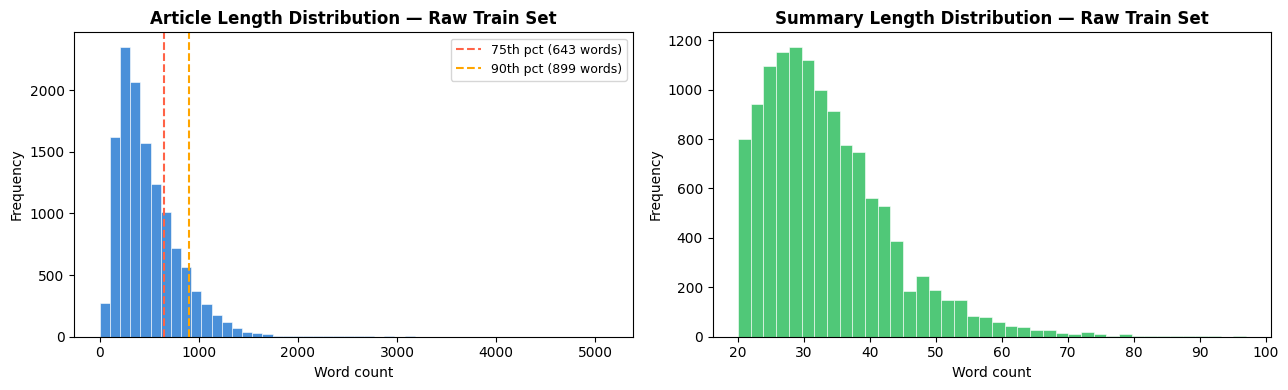

Plot saved: eda_raw.png


In [4]:
art_words = [len(x[ARTICLE_COL].split()) for x in raw["train"]]
sum_words = [len(x[SUMMARY_COL].split()) for x in raw["train"]]

print("Article word-count stats (train):")
print(f"  Min      : {min(art_words)}")
print(f"  Mean     : {np.mean(art_words):.0f}")
print(f"  Median   : {np.median(art_words):.0f}")
print(f"  75th pct : {np.percentile(art_words, 75):.0f}")
print(f"  90th pct : {np.percentile(art_words, 90):.0f}")
print(f"  Max      : {max(art_words)}")
print()
print("Summary word-count stats (train):")
print(f"  Mean     : {np.mean(sum_words):.0f}")
print(f"  Max      : {max(sum_words)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(art_words, bins=50, color="#4A90D9", edgecolor="white", linewidth=0.4)
axes[0].axvline(np.percentile(art_words, 75), color="tomato", linestyle="--",
                linewidth=1.5, label=f"75th pct ({np.percentile(art_words,75):.0f} words)")
axes[0].axvline(np.percentile(art_words, 90), color="orange", linestyle="--",
                linewidth=1.5, label=f"90th pct ({np.percentile(art_words,90):.0f} words)")
axes[0].set_title("Article Length Distribution — Raw Train Set", fontweight="bold")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=9)

axes[1].hist(sum_words, bins=40, color="#50C878", edgecolor="white", linewidth=0.4)
axes[1].set_title("Summary Length Distribution — Raw Train Set", fontweight="bold")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("eda_raw.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved: eda_raw.png")

---
## 7. Load Tokenizer & Filter Dataset

**Filtering rule:** keep articles with **token count ≤ 900**  
- Zero truncation — full article content is preserved  
- Leaves headroom inside BART-base's 1024-token limit  
- Training set stays well above the required 1,000 samples  
- Same rule applied uniformly to train, validation, and test

In [5]:
from transformers import BartTokenizer

MODEL_NAME        = "facebook/bart-base"
MAX_INPUT_TOKENS  = 900
MAX_TARGET_TOKENS = 128

tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded : {MODEL_NAME}")

def within_token_limit(example):
    ids = tokenizer(example[ARTICLE_COL], truncation=False)["input_ids"]
    return len(ids) <= MAX_INPUT_TOKENS

print(f"Filtering — keeping articles with token count <= {MAX_INPUT_TOKENS} ...")

filtered_train = raw["train"].filter(within_token_limit)
filtered_val   = raw["validation"].filter(within_token_limit)
filtered_test  = raw["test"].filter(within_token_limit)

print()
print("After filtering:")
print(f"  Train      : {len(raw['train']):,} -> {len(filtered_train):,} samples")
print(f"  Validation : {len(raw['validation']):,} -> {len(filtered_val):,} samples")
print(f"  Test       : {len(raw['test']):,} -> {len(filtered_test):,} samples")

assert len(filtered_train) > 1000, "Training samples < 1000!"
print()
print("Train > 1,000 samples. Filtering criteria satisfied.")

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded : facebook/bart-base
Filtering — keeping articles with token count <= 900 ...


Filter:   0%|          | 0/12565 [00:00<?, ? examples/s]

Filter:   0%|          | 0/898 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4487 [00:00<?, ? examples/s]


After filtering:
  Train      : 12,565 -> 9,265 samples
  Validation : 898 -> 658 samples
  Test       : 4,487 -> 3,257 samples

Train > 1,000 samples. Filtering criteria satisfied.


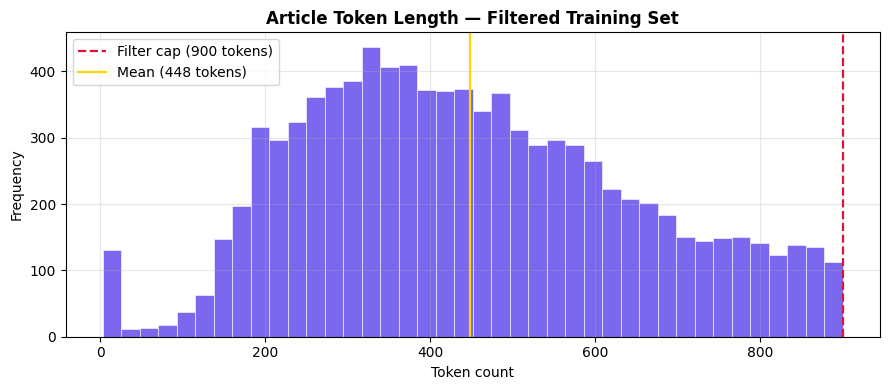

Mean token length : 448.3
Max  token length : 900


In [6]:
tok_lens = [len(tokenizer(x[ARTICLE_COL], truncation=False)["input_ids"]) for x in filtered_train]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tok_lens, bins=40, color="#7B68EE", edgecolor="white", linewidth=0.4)
ax.axvline(MAX_INPUT_TOKENS, color="crimson", linestyle="--", linewidth=1.6,
           label=f"Filter cap ({MAX_INPUT_TOKENS} tokens)")
ax.axvline(np.mean(tok_lens), color="gold", linestyle="-", linewidth=1.6,
           label=f"Mean ({np.mean(tok_lens):.0f} tokens)")
ax.set_title("Article Token Length — Filtered Training Set", fontweight="bold")
ax.set_xlabel("Token count")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("filtered_token_lengths.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Mean token length : {np.mean(tok_lens):.1f}")
print(f"Max  token length : {max(tok_lens)}")

---
## 8. Tokenize the Dataset

In [7]:
def preprocess(batch):
    model_inputs = tokenizer(
        batch[ARTICLE_COL],
        max_length=MAX_INPUT_TOKENS,
        truncation=True,
        padding="max_length"
    )
    labels = tokenizer(
        text_target=batch[SUMMARY_COL],
        max_length=MAX_TARGET_TOKENS,
        truncation=True,
        padding="max_length"
    )
    # -100 tells the loss to ignore padding positions
    model_inputs["labels"] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in ids]
        for ids in labels["input_ids"]
    ]
    return model_inputs

print("Tokenizing all splits ...")
cols = filtered_train.column_names

tokenized_train = filtered_train.map(preprocess, batched=True, remove_columns=cols)
tokenized_val   = filtered_val.map(preprocess,   batched=True, remove_columns=cols)
tokenized_test  = filtered_test.map(preprocess,  batched=True, remove_columns=cols)

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

print("Done.")
print(f"Output features : {list(tokenized_train.features.keys())}")
print(f"Train samples   : {len(tokenized_train):,}")

Tokenizing all splits ...


Map:   0%|          | 0/9265 [00:00<?, ? examples/s]

Map:   0%|          | 0/658 [00:00<?, ? examples/s]

Map:   0%|          | 0/3257 [00:00<?, ? examples/s]

Done.
Output features : ['input_ids', 'attention_mask', 'labels']
Train samples   : 9,265


---
## 9. Load Pretrained BART Model

In [8]:
from transformers import BartForConditionalGeneration

model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model loaded    : {MODEL_NAME}")
print(f"Total params    : {total / 1e6:.1f}M")
print(f"Trainable params: {trainable / 1e6:.1f}M")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Model loaded    : facebook/bart-base
Total params    : 139.4M
Trainable params: 139.4M


---
## 10. Define compute_metrics


In [9]:
import evaluate

rouge_metric = evaluate.load("rouge")


def safe_decode(ids_array, tok):
    """Decode token id arrays safely — handles -100 padding and out-of-range values."""
    ids_array = np.where(ids_array < 0, tok.pad_token_id, ids_array)
    ids_array = np.clip(ids_array, 0, tok.vocab_size - 1)
    return tok.batch_decode(ids_array.tolist(), skip_special_tokens=True)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    decoded_preds  = safe_decode(predictions, tokenizer)
    decoded_labels = safe_decode(labels,      tokenizer)

    # ROUGE expects newline-separated sentences
    decoded_preds  = ["\n".join(p.strip().split(".")) for p in decoded_preds]
    decoded_labels = ["\n".join(l.strip().split(".")) for l in decoded_labels]

    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    result = {k: round(v, 4) for k, v in result.items()}
    result["gen_len"] = round(np.mean([np.count_nonzero(p >= 0) for p in predictions]), 2)
    return result


print("compute_metrics defined.")
print("Tracks : ROUGE-1, ROUGE-2, ROUGE-L, ROUGE-Lsum, gen_len")

compute_metrics defined.
Tracks : ROUGE-1, ROUGE-2, ROUGE-L, ROUGE-Lsum, gen_len


---
## 11. Fine-Tune with Seq2SeqTrainer

In [10]:
from transformers import (
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bart-ilsum-checkpoints",
    num_train_epochs=5,                    # increased to 5
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=300,
    weight_decay=0.01,
    learning_rate=3e-5,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rouge2",
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_TOKENS,
    fp16=True,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer initialised.")
print(f"  Epochs            : {training_args.num_train_epochs}")
print(f"  Train batch size  : {training_args.per_device_train_batch_size}")
print(f"  Learning rate     : {training_args.learning_rate}")
print(f"  Mixed precision   : {training_args.fp16}")
print(f"  Best model metric : {training_args.metric_for_best_model}")

Trainer initialised.
  Epochs            : 5
  Train batch size  : 8
  Learning rate     : 3e-05
  Mixed precision   : True
  Best model metric : rouge2


In [11]:
print("Starting fine-tuning ...")
train_result = trainer.train()

print()
print("Training complete.")
print(f"  Steps completed : {train_result.global_step}")
print(f"  Training loss   : {train_result.training_loss:.4f}")
print(f"  Time taken      : {train_result.metrics['train_runtime'] / 60:.1f} minutes")

Starting fine-tuning ...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,0.713662,0.295579,0.465200,0.333100,0.414700,0.421700,54.190000
2,0.577782,0.273841,0.489000,0.366700,0.443300,0.449600,55.880000
3,0.500074,0.274997,0.494800,0.372200,0.448100,0.455900,57.280000
4,0.447455,0.266443,0.490400,0.371900,0.446600,0.450900,55.510000
5,0.383996,0.274190,0.500800,0.382300,0.456000,0.462200,56.300000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



Training complete.
  Steps completed : 2900
  Training loss   : 0.5751
  Time taken      : 80.2 minutes


---
## 12. Training & Validation Loss Curve

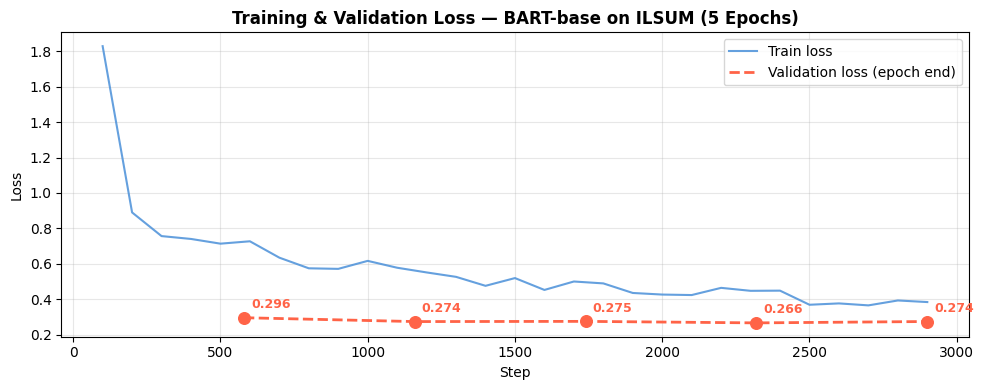

In [12]:
log = trainer.state.log_history

train_steps  = [x["step"] for x in log if "loss" in x and "eval_loss" not in x]
train_losses = [x["loss"] for x in log if "loss" in x and "eval_loss" not in x]
eval_steps   = [x["step"] for x in log if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_steps, train_losses, color="#4A90D9", linewidth=1.5,
        label="Train loss", alpha=0.85)
ax.plot(eval_steps, eval_losses, color="tomato", linewidth=2.0,
        linestyle="--", label="Validation loss (epoch end)")
ax.scatter(eval_steps, eval_losses, color="tomato", zorder=5, s=70)
for step, loss in zip(eval_steps, eval_losses):
    ax.annotate(f"{loss:.3f}", (step, loss),
                textcoords="offset points", xytext=(5, 7),
                fontsize=9, color="tomato", fontweight="bold")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss — BART-base on ILSUM (5 Epochs)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 13. Validation ROUGE Scores per Epoch

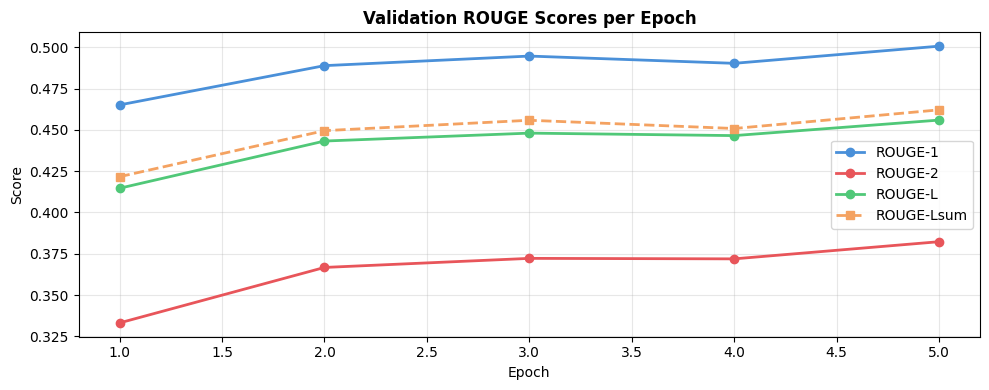

Validation ROUGE by epoch:
  Epoch 1  ->  R1=0.4652   R2=0.3331   RL=0.4147
  Epoch 2  ->  R1=0.4890   R2=0.3667   RL=0.4433
  Epoch 3  ->  R1=0.4948   R2=0.3722   RL=0.4481
  Epoch 4  ->  R1=0.4904   R2=0.3719   RL=0.4466
  Epoch 5  ->  R1=0.5008   R2=0.3823   RL=0.4560

Best ROUGE-2 : 0.3823  at Epoch 5


In [13]:
epoch_entries = [x for x in log if "eval_rouge1" in x]

if epoch_entries:
    epochs    = [x["epoch"]         for x in epoch_entries]
    rouge1    = [x["eval_rouge1"]    for x in epoch_entries]
    rouge2    = [x["eval_rouge2"]    for x in epoch_entries]
    rougeL    = [x["eval_rougeL"]    for x in epoch_entries]
    rougeLsum = [x["eval_rougeLsum"] for x in epoch_entries]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, rouge1,    marker="o", label="ROUGE-1",    color="#4A90D9", linewidth=2)
    ax.plot(epochs, rouge2,    marker="o", label="ROUGE-2",    color="#E8555A", linewidth=2)
    ax.plot(epochs, rougeL,    marker="o", label="ROUGE-L",    color="#50C878", linewidth=2)
    ax.plot(epochs, rougeLsum, marker="s", label="ROUGE-Lsum", color="#F4A261",
            linewidth=2, linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_title("Validation ROUGE Scores per Epoch", fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("val_rouge_per_epoch.png", dpi=120, bbox_inches="tight")
    plt.show()

    print("Validation ROUGE by epoch:")
    for i, ep in enumerate(epochs):
        print(f"  Epoch {ep:.0f}  ->  R1={rouge1[i]:.4f}   R2={rouge2[i]:.4f}   RL={rougeL[i]:.4f}")
    best_idx = rouge2.index(max(rouge2))
    print(f"\nBest ROUGE-2 : {max(rouge2):.4f}  at Epoch {epochs[best_idx]:.0f}")
else:
    print("No per-epoch ROUGE data found in log history.")

---
## 14. Evaluate on Test Set (ROUGE)

In [14]:
print("Running prediction on test set ...")
test_output  = trainer.predict(tokenized_test)
test_metrics = test_output.metrics

pred_ids  = test_output.predictions
label_ids = test_output.label_ids

print()
print("Test Set Results (ROUGE)")
print("-" * 38)
for k, v in test_metrics.items():
    if not isinstance(v, float):
        continue
    label = k.replace("predict_", "").replace("test_", "")
    print(f"  {label:<22} : {v:.4f}")

Running prediction on test set ...



Test Set Results (ROUGE)
--------------------------------------
  loss                   : 0.2646
  rouge1                 : 0.5011
  rouge2                 : 0.3764
  rougeL                 : 0.4522
  rougeLsum              : 0.4575
  gen_len                : 54.5700
  runtime                : 1030.1496
  samples_per_second     : 3.1620
  steps_per_second       : 0.1980


---
## 15. BERTScore on Test Set

In [15]:
from bert_score import score as bert_score_fn

decoded_preds  = safe_decode(pred_ids,  tokenizer)
decoded_labels = safe_decode(label_ids, tokenizer)

print("Computing BERTScore (distilbert-base-uncased) — ~1-2 min ...")
P, R, F1 = bert_score_fn(
    decoded_preds,
    decoded_labels,
    lang="en",
    model_type="distilbert-base-uncased",
    verbose=False
)

print()
print("BERTScore — Test Set")
print("-" * 30)
print(f"  Precision : {P.mean().item():.4f}")
print(f"  Recall    : {R.mean().item():.4f}")
print(f"  F1        : {F1.mean().item():.4f}")

Computing BERTScore (distilbert-base-uncased) — ~1-2 min ...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BERTScore — Test Set
------------------------------
  Precision : 0.8489
  Recall    : 0.8369
  F1        : 0.8425


---
## 16. Test Metrics — Bar Chart

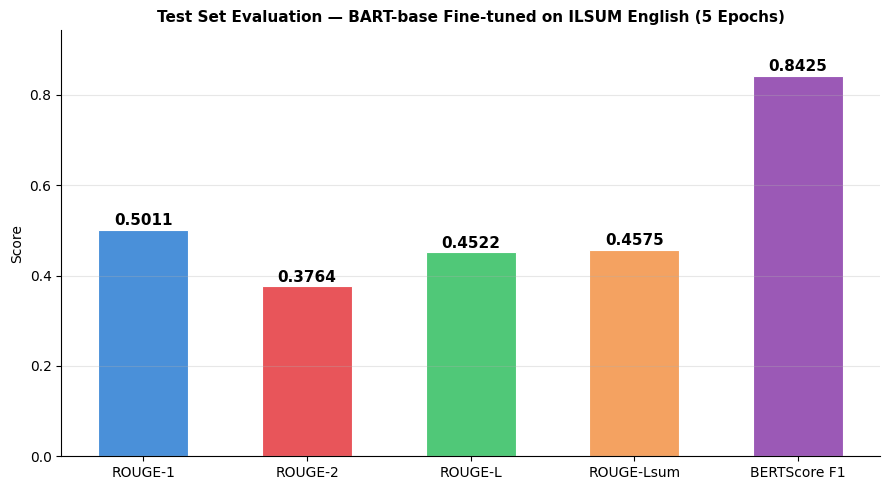

In [16]:
def get_metric(d, name):
    for prefix in ["predict_", "test_", ""]:
        if prefix + name in d:
            return d[prefix + name]
    return 0.0

metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum", "BERTScore F1"]
metric_vals  = [
    get_metric(test_metrics, "rouge1"),
    get_metric(test_metrics, "rouge2"),
    get_metric(test_metrics, "rougeL"),
    get_metric(test_metrics, "rougeLsum"),
    F1.mean().item()
]

colors = ["#4A90D9", "#E8555A", "#50C878", "#F4A261", "#9B59B6"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metric_names, metric_vals, color=colors,
              edgecolor="white", linewidth=0.8, width=0.55)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(metric_vals) + 0.10)
ax.set_title("Test Set Evaluation — BART-base Fine-tuned on ILSUM English (5 Epochs)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("test_metrics_bar.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 17. BERTScore F1 Distribution

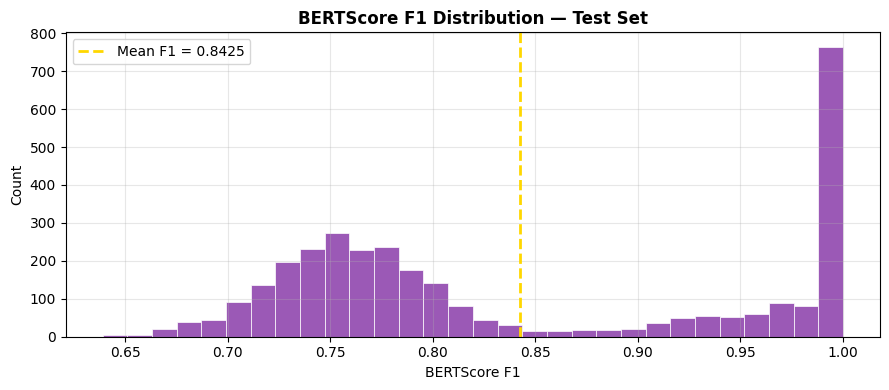

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(F1.numpy(), bins=30, color="#9B59B6", edgecolor="white", linewidth=0.5)
ax.axvline(F1.mean().item(), color="gold", linewidth=2.0, linestyle="--",
           label=f"Mean F1 = {F1.mean().item():.4f}")
ax.set_title("BERTScore F1 Distribution — Test Set", fontweight="bold")
ax.set_xlabel("BERTScore F1")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bertscore_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 18. Qualitative Examples — Generated vs Reference

In [18]:
print("Qualitative Comparison — 5 Test Examples")
print("=" * 72)

for i in range(5):
    article   = filtered_test[i][ARTICLE_COL]
    reference = filtered_test[i][SUMMARY_COL]
    generated = decoded_preds[i].strip()

    print(f"\nExample {i + 1}")
    print("-" * 72)
    print("Article (first 300 chars):")
    print(f"  {article[:300].strip()} ...")
    print()
    print("Reference summary:")
    print(f"  {reference.strip()}")
    print()
    print("Generated summary:")
    print(f"  {generated}")
    print("=" * 72)

Qualitative Comparison — 5 Test Examples

Example 1
------------------------------------------------------------------------
Article (first 300 chars):
  Fear shakes Mexico border city after violence leaves 18 deadFear has invaded the Mexican border city of Reynosa after gunmen in vehicles killed 14 people, including taxi drivers, workers and a nursing student, and security forces responded with operations that left four suspects dead.While this city ...

Reference summary:
  The attacks took place in several neighborhoods in eastern Reynosa, according to the Tamaulipas state agency that coordinates security forces, and sparked a deployment of the military, National Guard and state police across the city. Images posted on social media showed bodies in the streets.

Generated summary:
  Fear has invaded the Mexican border city of Reynosa after gunmen in vehicles killed 14 people, including taxi drivers, workers and a nursing student, and security forces responded with operations that le

---
## 19. Save the Fine-Tuned Model

In [19]:
SAVE_PATH = "./bart-ilsum-finetuned"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model and tokenizer saved to: {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./bart-ilsum-finetuned


---
## 20. Inference Demo

In [20]:
from transformers import BartForConditionalGeneration, BartTokenizer

inf_model     = BartForConditionalGeneration.from_pretrained(SAVE_PATH).to(device)
inf_tokenizer = BartTokenizer.from_pretrained(SAVE_PATH)
inf_model.eval()

print(f"Running inference on: {device}")


def generate_summary(text, max_new_tokens=100, num_beams=4, length_penalty=1.5):
    inputs = inf_tokenizer(
        text, return_tensors="pt",
        max_length=MAX_INPUT_TOKENS, truncation=True
    ).to(device)
    with torch.no_grad():
        ids = inf_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            length_penalty=length_penalty,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return inf_tokenizer.decode(ids[0], skip_special_tokens=True)


print()
print("=" * 72)
print("Inference Demo — 3 samples from test set")
print("=" * 72)

for i in [10, 20, 30]:
    sample    = filtered_test[i][ARTICLE_COL]
    reference = filtered_test[i][SUMMARY_COL]
    generated = generate_summary(sample)

    print(f"\nSample index : {i}")
    print("-" * 72)
    print("Article (first 350 chars):")
    print(f"  {sample[:350].strip()} ...")
    print()
    print("Reference summary:")
    print(f"  {reference.strip()}")
    print()
    print("Generated summary (beam=4, length_penalty=1.5):")
    print(f"  {generated}")
    print("=" * 72)

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Running inference on: cuda

Inference Demo — 3 samples from test set

Sample index : 10
------------------------------------------------------------------------
Article (first 350 chars):
  Sri Lanka is currently experiencing a Covid-19 surge due to the Delta variant. As per the latest records, the country registered 209 new deaths, the highest in a day so far, with 4,597 fresh cases. Amid an unabated increase of new Covid-19 cases and deaths, Sri Lanka has decided to extend the lockdown for another week till September 6.The Covid-19 ...

Reference summary:
  The Covid-19 Task Force met with President Gotabaya Rajapaksa on Friday after which it was decided to extend the quarantine lockdown that was to end on August 30.

Generated summary (beam=4, length_penalty=1.5):
  The Covid-19 Task Force met with President Gotabaya Rajapaksa on Friday after which it was decided to extend the quarantine lockdown that was to end on August 30.

Sample index : 20
--------------------------------------